# Is regional productivity a geography story or an industry composition story?

Manufacturing productivity varies widely across Japan's 47 prefectures. This notebook
asks how much of that is **which industries a region happens to host** and how much is
**how well it runs them**.

It is descriptive throughout: ranked magnitudes, an exact decomposition, and a variance
share. **No significance tests, no p-values, no causal claim.** That is deliberate — with
47 prefectures, magnitudes are informative where significance tests are not.

| Task | Question |
|---|---|
| 1 | How large are productivity differences *between* industries? |
| 2 | Is a prefecture productive because of its industries, or because it beats peers within them? |
| 3 | Once industry is held fixed, do large regional differences remain? |

### One comparison to avoid

It is tempting to compare the spread of industry productivity (5.90x) against the
spread of prefecture productivity (2.93x) and conclude industry matters about twice as
much. **That comparison is invalid**, and an earlier version of this project made it.

A prefecture figure is an employment-weighted average over 24 industries, so it is
mechanically compressed toward the mean; an industry figure is not. The two dispersions
sit at different levels of aggregation. The like-for-like comparison holds industry
fixed and asks how much prefectures differ *within* it, which is Task 3.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJ / "src"))

from viz_style import (apply_style, subtitle, source_note, ROMAJI, INDUSTRY_EN,
                       BLUE, ORANGE, GRAY_MARK, INK, INK_SECONDARY, INK_MUTED, AXIS, SURFACE)
from shift_share import load_cells, decompose, variance_shares

apply_style()
OUT = PROJ / "outputs" / "charts"
OUT.mkdir(parents=True, exist_ok=True)

YEARS = [2016, 2017, 2018, 2019]
cells = {y: load_cells(y) for y in YEARS}
d19 = cells[2019]

for y in YEARS:
    raw = pd.read_csv(PROJ / "processed_data" / f"manufacturing_{y}_table3-01.csv")
    print(f"{y}: {len(cells[y]):>5} usable cells of {len(raw)}  "
          f"({len(raw) - len(cells[y])} excluded: suppressed, nil, or zero employment)")

2016:  1091 usable cells of 1128  (37 excluded: suppressed, nil, or zero employment)
2017:  1095 usable cells of 1128  (33 excluded: suppressed, nil, or zero employment)
2018:  1092 usable cells of 1128  (36 excluded: suppressed, nil, or zero employment)
2019:  1093 usable cells of 1128  (35 excluded: suppressed, nil, or zero employment)


Cells are kept only where value added and employment are both flagged `ok` and
employment is positive. Suppression is concentrated in thin prefecture x industry
cells, so it is **not** missing-at-random; excluded cells are never zero-filled.

Coverage for the five prefectures decomposed in Task 2:

In [2]:
panel = pd.read_csv(PROJ / "processed_data" / "panel_prefecture_year.csv",
                    dtype={"prefecture_code": str})
p19 = panel[panel.year == 2019]
focus_jp = ["愛知", "東京", "大阪", "山口", "徳島"]
cov = p19[p19.prefecture_name.isin(focus_jp)][["prefecture_name", "suppressed_cells",
                                               "va_coverage_pct"]].copy()
cov["prefecture"] = cov.prefecture_name.map(ROMAJI)
display(cov[["prefecture", "suppressed_cells", "va_coverage_pct"]]
        .rename(columns={"suppressed_cells": "suppressed cells",
                         "va_coverage_pct": "value added coverage (%)"})
        .sort_values("value added coverage (%)").round(3).reset_index(drop=True))
print("Coverage is >=99.7% everywhere, so suppression does not drive any result below.")

,prefecture,suppressed cells,value added coverage (%)
0,Yamaguchi,2.0,99.736
1,Tokushima,3.0,99.841
2,Aichi,0.0,100.000
3,Osaka,0.0,100.000
4,Tokyo,0.0,100.000


Coverage is >=99.7% everywhere, so suppression does not drive any result below.


## Task 1 — How large are productivity differences between industries?

### Chart 5 — Manufacturing productivity by industry

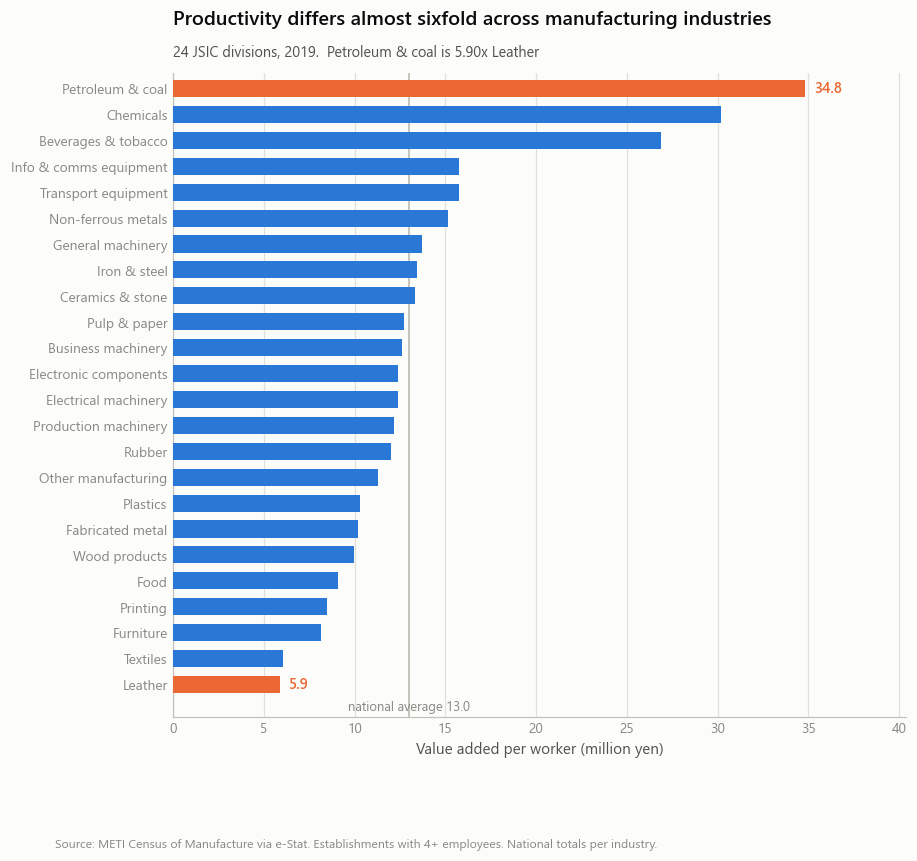

Between-industry span: 5.90x  (34.8 down to 5.9)


In [3]:
nat = (d19.groupby("industry_code")
       .apply(lambda g: g.value_added.sum() / g.employment.sum(), include_groups=False)
       .rename("va_per_worker").reset_index())
nat["industry"] = nat.industry_code.map(INDUSTRY_EN)
nat = nat.sort_values("va_per_worker")
national = d19.value_added.sum() / d19.employment.sum()
span = nat.va_per_worker.max() / nat.va_per_worker.min()

hi, lo = nat.industry.iloc[-1], nat.industry.iloc[0]
colors = [ORANGE if i in (hi, lo) else BLUE for i in nat.industry]

fig, ax = plt.subplots(figsize=(8.6, 7.6))
ax.barh(nat.industry, nat.va_per_worker, color=colors, height=0.66, zorder=3)
ax.axvline(national, color=AXIS, linewidth=1.2, zorder=2)
ax.set_ylim(-1.25, len(nat) - 0.4)
ax.annotate(f"national average {national:.1f}", xy=(national, -0.85),
            ha="center", va="center", fontsize=8.5, color=INK_MUTED)
ax.set_xlabel("Value added per worker (million yen)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, nat.va_per_worker.max() * 1.16)

for ind, v in zip(nat.industry, nat.va_per_worker):
    if ind in (hi, lo):
        ax.annotate(f"{v:.1f}", (v, ind), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9.5, fontweight="semibold", color=ORANGE)

ax.set_title("Productivity differs almost sixfold across manufacturing industries")
subtitle(ax, f"24 JSIC divisions, 2019.  {hi} is {span:.2f}x {lo}")
source_note(fig, "Source: METI Census of Manufacture via e-Stat. Establishments with "
                 "4+ employees. National totals per industry.")
fig.savefig(OUT / "chart5_industry_productivity.png")
plt.show()
print(f"Between-industry span: {span:.2f}x  "
      f"({nat.va_per_worker.max():.1f} down to {nat.va_per_worker.min():.1f})")

Confirms the 5.90x figure. Capital-intensive process industries sit at the top;
labour-intensive assembly and consumer goods at the bottom.

**This is the *potential* for industry mix to matter.** Whether it actually does
depends on how concentrated prefectures are, which Task 2 measures.

## Task 2 — Mix or performance?

A prefecture's productivity gap against the national benchmark splits exactly in two:

```
mix    = SUM (s_pi - s_Ni) * pi_Ni      does it hold industries that pay well nationally?
within = SUM  s_pi * (pi_pi - pi_Ni)    does it beat national rates inside those industries?
gap    = mix + within                   exactly
```

`src/shift_share.py` asserts that identity per prefecture. An earlier version of this
analysis left a residual of 1.37 by measuring the gap against global national
productivity while decomposing over a prefecture's surviving industry subset — two
different benchmarks. The module now fails loudly rather than producing plausible
numbers that do not add up.

### Chart 6 — Industry mix vs within-industry performance

identity check: max |residual| across 47 prefectures = 4.00e-15


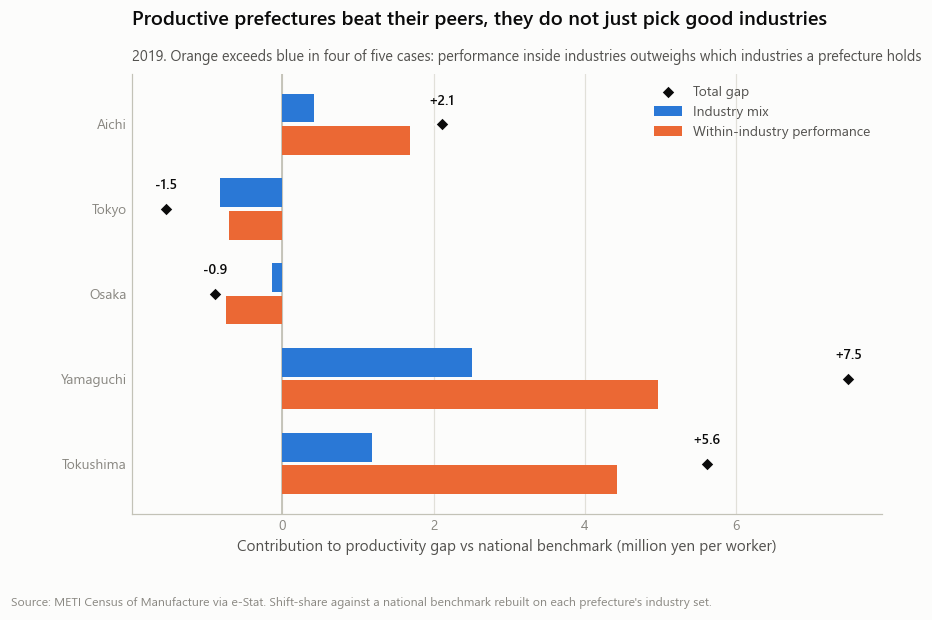

,va_per_worker,benchmark,gap,mix_effect,within_effect,dominant
prefecture,,,,,,
Aichi,15.10,12.99,2.10,0.42,1.69,within
Tokyo,11.45,12.99,-1.54,-0.83,-0.71,mix
Osaka,12.10,12.99,-0.89,-0.14,-0.75,within
Yamaguchi,20.45,12.98,7.48,2.51,4.97,within
Tokushima,18.44,12.83,5.61,1.19,4.42,within


In [4]:
dec19 = decompose(d19, 2019)
dec19["prefecture"] = dec19.prefecture_name.map(ROMAJI)
print(f"identity check: max |residual| across 47 prefectures = "
      f"{dec19.residual.abs().max():.2e}")

focus = ["Aichi", "Tokyo", "Osaka", "Yamaguchi", "Tokushima"]
f = dec19[dec19.prefecture.isin(focus)].set_index("prefecture").loc[focus].iloc[::-1]

y = np.arange(len(f)); h = 0.34
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.axvline(0, color=AXIS, linewidth=1.2, zorder=2)
ax.barh(y + h/2 + 0.02, f.mix_effect, height=h, color=BLUE,
        label="Industry mix", zorder=3)
ax.barh(y - h/2 - 0.02, f.within_effect, height=h, color=ORANGE,
        label="Within-industry performance", zorder=3)
ax.scatter(f.gap, y, marker="D", s=46, color=INK, zorder=4,
           edgecolor=SURFACE, linewidth=1.5, label="Total gap")
ax.set_yticks(y); ax.set_yticklabels(f.index)
ax.set_xlabel("Contribution to productivity gap vs national benchmark (million yen per worker)")
ax.grid(axis="y", visible=False)
# Upper right is the only empty quadrant: Aichi's row is short and Yamaguchi's
# marker sits far right but low. Lower right would land on Tokushima, and put the
# legend's own diamond beside Tokushima's real one.
ax.legend(loc="upper right", ncol=1)

for i, (_, r) in enumerate(f.iterrows()):
    ax.annotate(f"{r.gap:+.1f}", (r.gap, i), xytext=(0, 13),
                textcoords="offset points", ha="center", fontsize=9,
                color=INK, fontweight="semibold")

ax.set_title("Productive prefectures beat their peers, they do not just pick good industries")
subtitle(ax, "2019. Orange exceeds blue in four of five cases: performance inside "
             "industries outweighs which industries a prefecture holds")
source_note(fig, "Source: METI Census of Manufacture via e-Stat. Shift-share against a "
                 "national benchmark rebuilt on each prefecture's industry set.")
fig.savefig(OUT / "chart6_shift_share_decomposition.png")
plt.show()
display(f[["va_per_worker", "benchmark", "gap", "mix_effect", "within_effect", "dominant"]]
        .iloc[::-1].round(2))

Read Aichi first, because it is the case everyone assumes they understand. Aichi sits
+2.10 above the benchmark, and only **+0.42** of that comes from being concentrated in
transport equipment. The remaining **+1.69** is attributed to performance inside the
industries it holds.

**That +1.69 needs one qualification.** The two-way decomposition above gives the
`within` term the prefecture's own employment weights, which folds the *interaction*
between composition and performance into it. Separating the interaction out:

| Prefecture | Mix | Within | Interaction |
|---|---|---|---|
| Aichi | +0.42 | **+1.04** | **+0.65** |
| Yamaguchi | +2.51 | +1.26 | **+3.71** |
| Tokyo | −0.83 | −0.96 | +0.25 |

So Aichi is roughly **a fifth industry mix, half within-industry performance, and a
third interaction** — not "80% from being good at it". The ranking of mix against
within is unchanged, but the size of the within term is overstated by the two-way form.

Yamaguchi is the clearest case: most of its advantage is *interaction*. It is both
concentrated in chemicals and unusually good at chemicals, and the two reinforce. That
is more interesting than either term alone, and the two-way decomposition hides it.

Tokyo is the one case where mix dominates, pointing the other way: its deficit is
mostly structural, a manufacturing base weighted toward printing and low-value urban
industry.

In [5]:
print("All 47 prefectures, 2019:")
print(f"  sd(mix effect)    = {dec19.mix_effect.std():.3f}")
print(f"  sd(within effect) = {dec19.within_effect.std():.3f}")
print(f"  ratio             = {dec19.within_effect.std()/dec19.mix_effect.std():.2f}x")
print(f"  within-dominant   = {(dec19.dominant=='within').sum()} of 47 prefectures")

print("\nStability across all four years:")
rows = []
for y_ in YEARS:
    dy = decompose(cells[y_], y_)
    rows.append({"year": y_, "sd(mix)": dy.mix_effect.std(),
                 "sd(within)": dy.within_effect.std(),
                 "ratio": dy.within_effect.std()/dy.mix_effect.std(),
                 "within-dominant of 47": int((dy.dominant=='within').sum()),
                 "max |residual|": dy.residual.abs().max()})
display(pd.DataFrame(rows).set_index("year").round({"sd(mix)":3,"sd(within)":3,"ratio":2}))
print("The ranking is stable in every year, so it is not a 2019 artifact.")

All 47 prefectures, 2019:
  sd(mix effect)    = 0.867
  sd(within effect) = 2.215
  ratio             = 2.56x
  within-dominant   = 37 of 47 prefectures

Stability across all four years:


,sd(mix),sd(within),ratio,within-dominant of 47,max |residual|
year,,,,,
2016,0.904,2.190,2.42,37,4.440892e-15
2017,0.979,2.252,2.30,36,3.996803e-15
2018,0.921,2.310,2.51,36,3.552714e-15
2019,0.867,2.215,2.56,37,3.996803e-15


The ranking is stable in every year, so it is not a 2019 artifact.


## Task 3 — Once industry is fixed, do regional differences remain?

### Chart 7 — Spread of prefecture productivity within each industry

2 cells with non-positive value added excluded (petroleum refining, where depreciation exceeds margin)


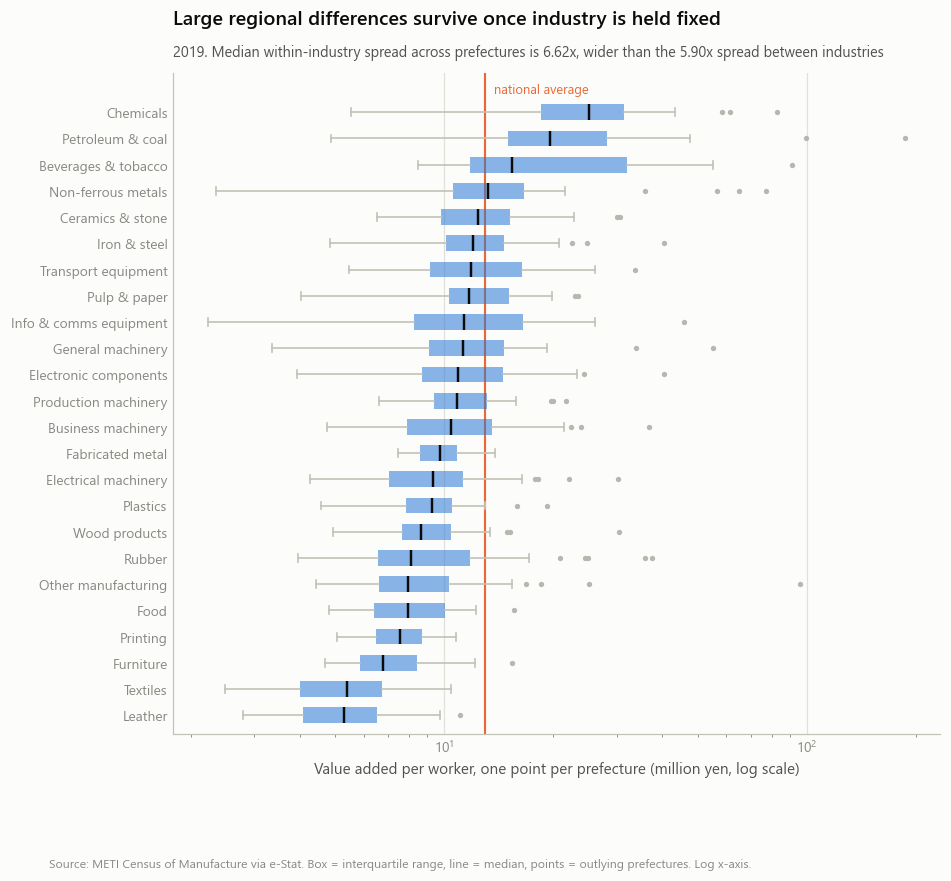

Within-industry spread across prefectures (max/min):
  median across 24 industries : 6.62x
  range                       : 1.85x to 38.41x
  industries exceeding the 5.90x between-industry span : 14 of 24


In [6]:
pos = d19[d19.value_added > 0].copy()
print(f"{len(d19) - len(pos)} cells with non-positive value added excluded "
      f"(petroleum refining, where depreciation exceeds margin)")
pos["vapw"] = pos.value_added / pos.employment
order = pos.groupby("industry_code").vapw.median().sort_values().index
data = [pos.loc[pos.industry_code == ic, "vapw"].values for ic in order]
labels = [INDUSTRY_EN[ic] for ic in order]

ratios = pos.groupby("industry_code").vapw.agg(lambda s: s.max()/s.min())
med_ratio = ratios.median()

fig, ax = plt.subplots(figsize=(9.0, 7.8))
bp = ax.boxplot(data, vert=False, tick_labels=labels, widths=0.6, patch_artist=True,
                flierprops=dict(marker="o", markersize=3.5, markerfacecolor=GRAY_MARK,
                                markeredgecolor="none"),
                medianprops=dict(color=INK, linewidth=1.6),
                boxprops=dict(facecolor=BLUE, edgecolor=BLUE, alpha=0.55, linewidth=0),
                whiskerprops=dict(color=AXIS, linewidth=1.1),
                capprops=dict(color=AXIS, linewidth=1.1))
ax.axvline(national, color=ORANGE, linewidth=1.4, zorder=1)
# Boxplot positions run 1..n, so label the reference line just above the top box
# with the limit widened to hold it. Placing it below the axis puts it outside.
ax.set_ylim(0.3, len(order) + 1.5)
ax.annotate("national average", xy=(national, len(order) + 0.85), xytext=(6, 0),
            textcoords="offset points", fontsize=8.5, color=ORANGE, va="center")
ax.set_xscale("log")
ax.set_xlabel("Value added per worker, one point per prefecture (million yen, log scale)")
ax.grid(axis="y", visible=False)
ax.set_title("Large regional differences survive once industry is held fixed")
subtitle(ax, f"2019. Median within-industry spread across prefectures is "
             f"{med_ratio:.2f}x, wider than the {span:.2f}x spread between industries")
source_note(fig, "Source: METI Census of Manufacture via e-Stat. Box = interquartile "
                 "range, line = median, points = outlying prefectures. Log x-axis.")
fig.savefig(OUT / "chart7_within_industry_spread.png")
plt.show()

print(f"Within-industry spread across prefectures (max/min):")
print(f"  median across 24 industries : {med_ratio:.2f}x")
print(f"  range                       : {ratios.min():.2f}x to {ratios.max():.2f}x")
print(f"  industries exceeding the {span:.2f}x between-industry span : "
      f"{(ratios > span).sum()} of 24")

The answer to Task 3 is yes, emphatically. The median industry shows a **6.6x** gap
between its best and worst prefecture — wider than the 5.90x gap between industries.
Fourteen of 24 industries individually exceed the entire between-industry span.

Regional effects are real and large. They are worth modelling.

## Variance decomposition

One number for the whole question. What share of the variance in log value added per
worker, across all prefecture x industry cells, is accounted for by industry identity
versus prefecture identity?

This is **descriptive sums of squares**, employment-weighted. No model is fitted, no
coefficients or p-values are produced, and the two shares do not sum to 1 because
industry and prefecture overlap. It is not the planned fixed-effects analysis.

In [7]:
vs = variance_shares(d19)
print(f"cells used: {vs['cells_used']}  "
      f"(dropped {vs['cells_dropped_nonpositive_va']} with non-positive value added)")
print()
print(f"  industry means alone   explain {vs['industry_share']:6.1%} of total variance")
print(f"  prefecture means alone explain {vs['prefecture_share']:6.1%} of total variance")
print(f"  ratio industry/prefecture = {vs['industry_share']/vs['prefecture_share']:.2f}x")

cells used: 1091  (dropped 2 with non-positive value added)

  industry means alone   explain  51.6% of total variance
  prefecture means alone explain  15.0% of total variance
  ratio industry/prefecture = 3.44x


## Reconciling the two answers

The variance decomposition says **industry** dominates (51.6% vs 15.0%). The
shift-share says **within-industry performance** dominates (2.6x the mix effect). Both
are correct, because they ask different questions.

| Level | Question | Answer |
|---|---|---|
| **Cell** | Why is *this* prefecture-industry cell productive? | Mostly which industry it is |
| **Aggregate** | Why is *this prefecture's overall* productivity above or below average? | Mostly how well it performs within its industries |

They differ because **prefectures are not specialized enough** for large
between-industry differences to translate into large aggregate mix effects. Herfindahl
indices run from 0.06 to 0.25, so every prefecture holds a broad industrial base. A
prefecture would have to be overwhelmingly concentrated in chemicals to inherit the
chemical industry's productivity level, and none is.

So the mix effect is damped by diversification, while within-industry differences pass
through undamped.

### What this supports

Holding industry fixed, the median industry still shows a **6.62x** gap between its
best and worst prefecture — wider than the 5.90x gap between industries, and 14 of 24
industries individually exceed it. **Regional variation is real and large.**

That is the foundation any new hypothesis should build on: there is substantial
within-industry, cross-prefecture variation to be explained, and explaining it requires
holding industry constant rather than comparing prefecture aggregates.

### What this notebook does not establish

It does not say *why* some prefectures outperform within an industry. Capital intensity,
plant scale, workforce composition and firm age are all untested candidates. Nor does it
support any claim about specialization: the decomposition measures where a prefecture's
advantage sits, not what causes it.